# OnTime — Model Comparison Notebook
**Target:** `avg_delay_seconds` (regression)

We load all weekly parquet files, engineer features, train multiple regression models, and compare them side-by-side so the best model can be selected for the `ml_service` API.

### Models evaluated
| # | Model | Why                                                        |
|---|-------|------------------------------------------------------------|
| 1 | Linear Regression | Fast baseline — shows if the problem is linearly separable |
| 2 | Ridge Regression | Baseline + L2 regularization                               |
| 3 | Random Forest | Handles non-linearity & categorical interactions well      |
| 4 | Gradient Boosting (XGBoost-style via sklearn) | Usually best on tabular data                               |
| 5 | LightGBM | Fast alternative to GBM, good with categoricals            |

> **Note on `holiday` column:** Currently all values are `'no'` because the aggregated weekly format makes individual holiday flagging unreliable. We will replace the column if/when it is fixed.

## Imports & Config

In [2]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import lightgbm as lgb
import joblib
import json

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)

sns.set_theme(style='whitegrid', palette='muted')

# ── CONFIG ─────────────────────────────────────────────────────────────────
DATA_DIR   = './data/final_data_updated'            # folder containing all weekly parquet/csv files
FILE_EXT   = 'parquet'                              # change to 'csv' if using csv files
TARGET_COL = 'avg_delay_seconds'
TEST_SIZE  = 0.2
RANDOM_STATE = 42
# ───────────────────────────────────────────────────────────────────────────

print('Libraries loaded ✓')

Libraries loaded ✓


## Load All Files

In [3]:
def load_all_files(data_dir: str, ext: str = 'parquet') -> pd.DataFrame:
    """Load all weekly files from data_dir into one DataFrame."""
    pattern = os.path.join(data_dir, f'*.{ext}')
    files = sorted(glob.glob(pattern))
    
    if not files:
        raise FileNotFoundError(f"No .{ext} files found in {data_dir}")
    
    frames = []
    for f in files:
        df = pd.read_parquet(f)

        # derive the source filename so we can debug later
        df['_source_file'] = os.path.basename(f)
        frames.append(df)
    
    combined = pd.concat(frames, ignore_index=True)
    print(f"Loaded {len(files)} files → {combined.shape[0]:,} rows × {combined.shape[1]} cols")
    return combined

df_raw = load_all_files(DATA_DIR, FILE_EXT)
df_raw.head(3)

Loaded 86 files → 2,988,763 rows × 13 cols


,month_period,day_of_week,route_name,direction,stop_id,stop_name,stop_sequence,hour,avg_delay_seconds,count,season,holiday,_source_file
0,2024-12,Tuesday,1,Downtown/South,103S,238 St,2.0,23.0,-38.714286,7,Winter,no,2024-12_Tuesday.parquet
1,2024-12,Tuesday,1,Downtown/South,104S,231 St,3.0,23.0,-33.571429,7,Winter,no,2024-12_Tuesday.parquet
2,2024-12,Tuesday,1,Downtown/South,106S,Marble Hill-225 St,4.0,23.0,-39.142857,7,Winter,no,2024-12_Tuesday.parquet


## Exploratory Data Analysis

In [4]:
print("=== Schema ===")
print(df_raw.dtypes)
print(f"\n=== Nulls ===")
print(df_raw.isnull().sum())
print(f"\n=== Target summary ===")
print(df_raw[TARGET_COL].describe())

=== Schema ===
month_period             str
day_of_week              str
route_name               str
direction                str
stop_id                  str
stop_name                str
stop_sequence        float64
hour                 float64
avg_delay_seconds    float64
count                  int64
season                   str
holiday                  str
_source_file             str
dtype: object

=== Nulls ===
month_period         0
day_of_week          0
route_name           0
direction            0
stop_id              0
stop_name            0
stop_sequence        0
hour                 0
avg_delay_seconds    0
count                0
season               0
holiday              0
_source_file         0
dtype: int64

=== Target summary ===
count    2.988763e+06
mean     1.356207e+01
std      6.660067e+01
min     -7.035000e+02
25%     -1.971053e+01
50%      5.965517e+00
75%      3.953333e+01
max      7.177500e+02
Name: avg_delay_seconds, dtype: float64


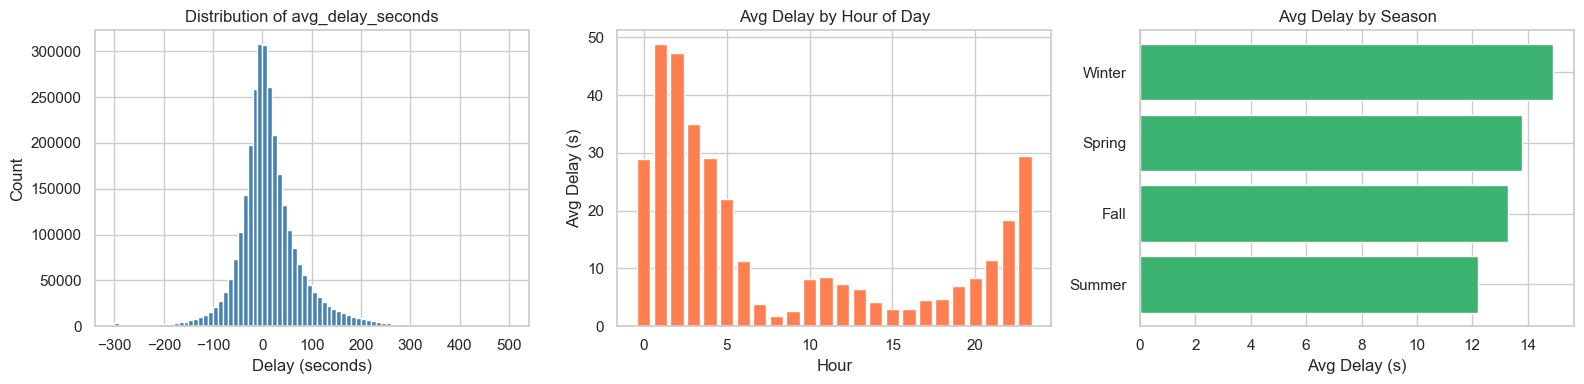

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribution of target
axes[0].hist(df_raw[TARGET_COL].clip(-300, 500), bins=80, color='steelblue', edgecolor='white')
axes[0].set_title("Distribution of avg_delay_seconds")
axes[0].set_xlabel("Delay (seconds)")
axes[0].set_ylabel("Count")

# Delay by hour
hour_means = df_raw.groupby('hour')[TARGET_COL].mean().sort_index()
axes[1].bar(hour_means.index, hour_means.values, color='coral')
axes[1].set_title("Avg Delay by Hour of Day")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Avg Delay (s)")

# Delay by season
season_means = df_raw.groupby('season')[TARGET_COL].mean().sort_values()
axes[2].barh(season_means.index, season_means.values, color='mediumseagreen')
axes[2].set_title("Avg Delay by Season")
axes[2].set_xlabel("Avg Delay (s)")

plt.tight_layout()
plt.show()

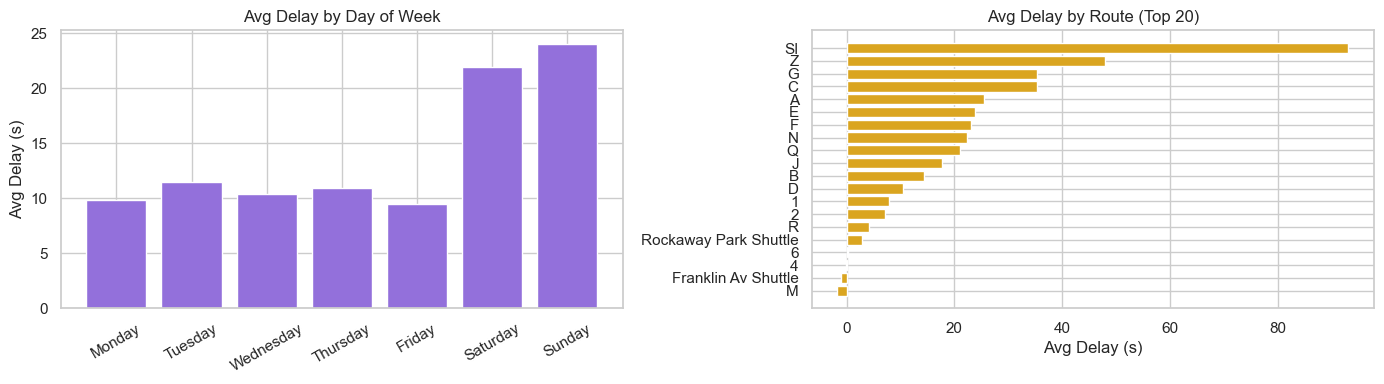

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Delay by day of week
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_means = df_raw.groupby('day_of_week')[TARGET_COL].mean().reindex(
    [d for d in dow_order if d in df_raw['day_of_week'].unique()]
)
axes[0].bar(dow_means.index, dow_means.values, color='mediumpurple')
axes[0].set_title("Avg Delay by Day of Week")
axes[0].set_ylabel("Avg Delay (s)")
axes[0].tick_params(axis='x', rotation=30)

# Delay by route
route_means = df_raw.groupby('route_name')[TARGET_COL].mean().sort_values(ascending=False).head(20)
axes[1].barh(route_means.index, route_means.values, color='goldenrod')
axes[1].set_title("Avg Delay by Route (Top 20)")
axes[1].set_xlabel("Avg Delay (s)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [7]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Separate month_period (month and year) into separate month and year columns
    if 'month_period' in df.columns:
        df['year']  = df['month_period'].str[:4].astype(int)
        df['month'] = df['month_period'].str[5:7].astype(int)

    # Cyclical encoding for hour (captures 23→0 wrap-around)
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

    # Cyclical encoding for month
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    #  Rush-hour flag
    df['is_rush_hour'] = df['hour'].isin([7, 8, 9, 16, 17, 18]).astype(int)

    # Late-night flag
    df['is_late_night'] = df['hour'].isin([0, 1, 2, 3, 4]).astype(int)

    # Label-encode high-cardinality categoricals
    cat_cols = ['route_name', 'direction', 'stop_id', 'day_of_week', 'season']
    le = LabelEncoder()
    for col in cat_cols:
        if col in df.columns:
            df[col + '_enc'] = le.fit_transform(df[col].astype(str))

    # ** Drop holiday (currently all 'no' — re-enable after fix) **
    # df['holiday_enc'] = (df['holiday'] == 'yes').astype(int)

    # Drop columns not used as features
    drop_cols = [
        'month_period', 'stop_name', 'holiday',   # low-signal or broken
        'route_name', 'direction', 'stop_id',     # replaced by _enc versions
        'day_of_week', 'season',
        '_source_file'
    ]
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    return df


df = engineer_features(df_raw)
print("Features after engineering:")
print(df.columns.tolist())
print("\nShape:", df.shape)
df.head()

Features after engineering:
['stop_sequence', 'hour', 'avg_delay_seconds', 'count', 'year', 'month', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'is_rush_hour', 'is_late_night', 'route_name_enc', 'direction_enc', 'stop_id_enc', 'day_of_week_enc', 'season_enc']

Shape: (2988763, 17)


,stop_sequence,hour,avg_delay_seconds,count,year,month,hour_sin,hour_cos,month_sin,month_cos,is_rush_hour,is_late_night,route_name_enc,direction_enc,stop_id_enc,day_of_week_enc,season_enc
0,2.0,23.0,-38.714286,7,2024,12,-0.258819,0.965926,-2.449294e-16,1.0,0,0,0,0,2,5,3
1,3.0,23.0,-33.571429,7,2024,12,-0.258819,0.965926,-2.449294e-16,1.0,0,0,0,0,4,5,3
2,4.0,23.0,-39.142857,7,2024,12,-0.258819,0.965926,-2.449294e-16,1.0,0,0,0,0,6,5,3
3,5.0,23.0,-33.571429,7,2024,12,-0.258819,0.965926,-2.449294e-16,1.0,0,0,0,0,8,5,3
4,6.0,23.0,-9.000000,7,2024,12,-0.258819,0.965926,-2.449294e-16,1.0,0,0,0,0,10,5,3


## Train / Test Split

In [8]:
# Drop any remaining nulls
df = df.dropna(subset=[TARGET_COL])

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")
print(f"Features: {X_train.shape[1]}")

Train: 2,391,010 rows | Test: 597,753 rows
Features: 16


## Model Definitions

In [9]:
models = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Ridge (α=10)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=10))
    ]),
    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        random_state=RANDOM_STATE
    ),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
}

print(f"\nModels to evaluate: {list(models.keys())}")


Models to evaluate: ['Linear Regression', 'Ridge (α=10)', 'Random Forest', 'Gradient Boosting', 'LightGBM']


## Training & Evaluation

In [10]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    """Fit and return a dict of metrics."""
    print(f'  Training {name}...', end=' ')
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    # Mean Absolute Percentage Error (ignore near-zero targets)
    mask = np.abs(y_test) > 5
    mape = np.mean(np.abs((y_test[mask] - preds[mask]) / y_test[mask])) * 100
    
    print(f'MAE={mae:.1f}s  RMSE={rmse:.1f}s  R²={r2:.4f}')
    return {
        'Model': name,
        'MAE (s)': round(mae, 2),
        'RMSE (s)': round(rmse, 2),
        'R²': round(r2, 4),
        'MAPE (%)': round(mape, 2),
        '_model': model,
        '_preds': preds
    }

print('Training all models...\n')
results = [evaluate_model(name, m, X_train, X_test, y_train, y_test)
           for name, m in models.items()]

results_df = pd.DataFrame(results).drop(columns=['_model', '_preds'])
results_df = results_df.sort_values('MAE (s)')
print("\n=== Results Summary ===")
results_df

Training all models...

  Training Linear Regression... MAE=43.6s  RMSE=64.5s  R²=0.0624
  Training Ridge (α=10)... MAE=43.6s  RMSE=64.5s  R²=0.0624
  Training Random Forest... MAE=36.3s  RMSE=53.9s  R²=0.3459
  Training Gradient Boosting... MAE=38.3s  RMSE=57.2s  R²=0.2639
  Training LightGBM... [LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017859 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 585
[LightGBM] [Info] Number of data points in the train set: 2391010, number of used features: 16
[LightGBM] [Info] Start training from score 13.560513
MAE=35.5s  RMSE=52.3s  R²=0.3842

=== Results Summary ===


,Model,MAE (s),RMSE (s),R²,MAPE (%)
4,LightGBM,35.49,52.30,0.3842,97.35
2,Random Forest,36.34,53.90,0.3459,100.57
3,Gradient Boosting,38.32,57.18,0.2639,101.63
0,Linear Regression,43.58,64.53,0.0624,109.20
1,Ridge (α=10),43.58,64.53,0.0624,109.20


## Visual Comparison

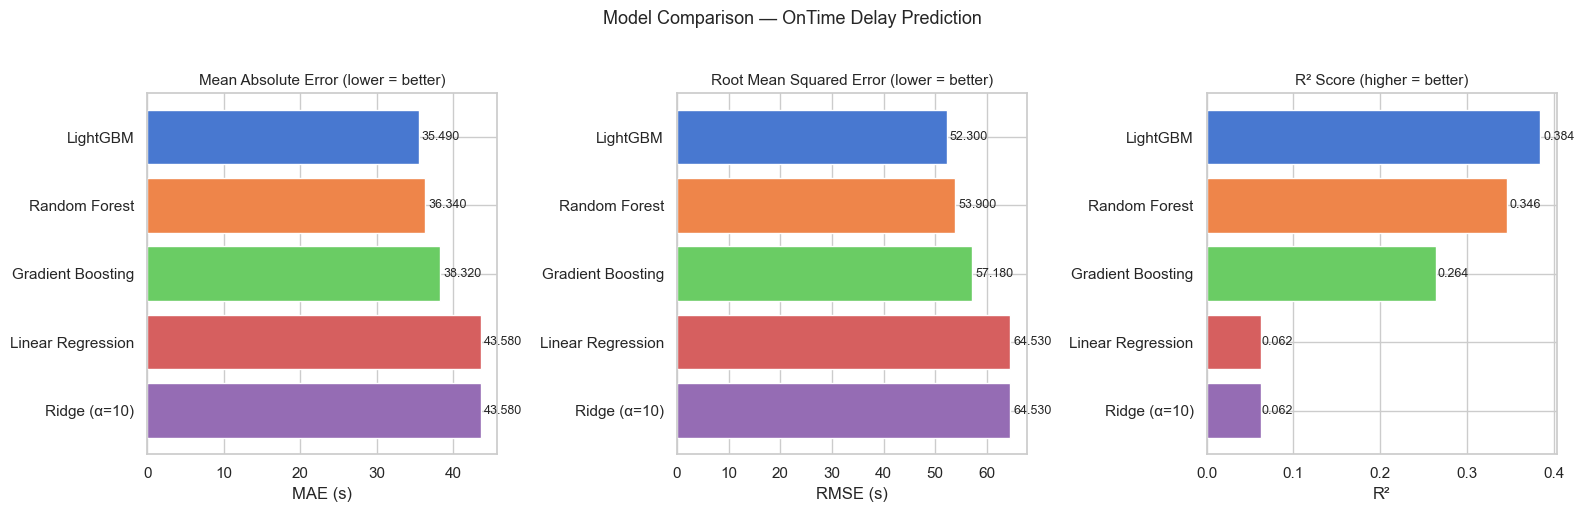

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_names = results_df['Model'].tolist()

colors = sns.color_palette('muted', len(model_names))

for ax, metric, title in zip(
    axes,
    ['MAE (s)', 'RMSE (s)', 'R²'],
    ['Mean Absolute Error (lower = better)',
     'Root Mean Squared Error (lower = better)',
     'R² Score (higher = better)']
):
    vals = results_df.set_index('Model')[metric].loc[model_names]
    bars = ax.barh(model_names, vals, color=colors)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(metric)
    ax.invert_yaxis()
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Model Comparison — OnTime Delay Prediction', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

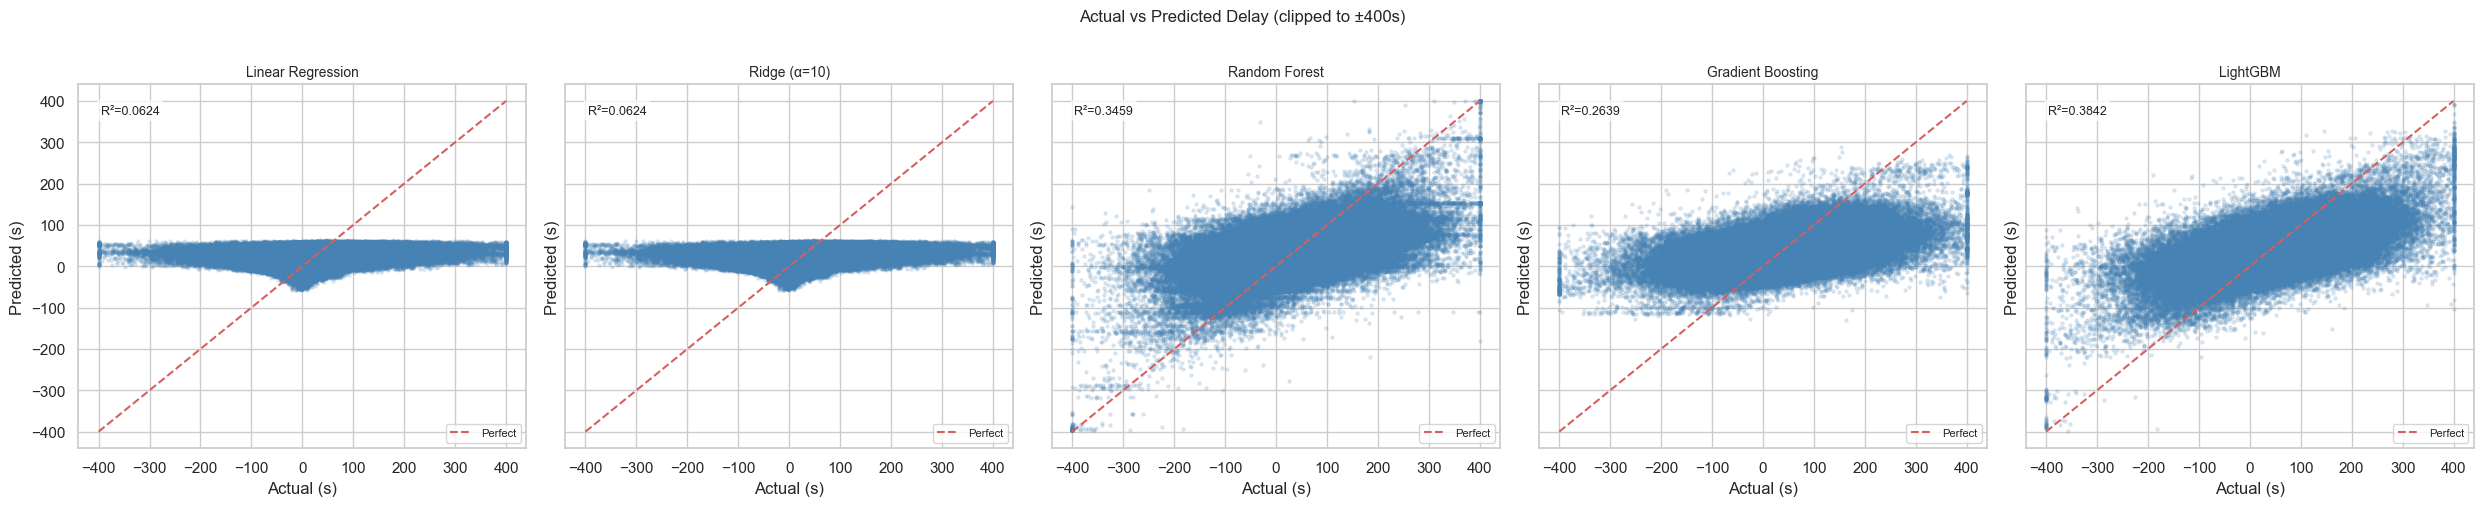

In [12]:
# Actual vs Predicted scatter for each model
n = len(results)
fig, axes = plt.subplots(1, n, figsize=(5*n, 5), sharey=True)
if n == 1: axes = [axes]

clip_val = 400
for ax, r in zip(axes, results):
    y_true_clipped = np.clip(y_test, -clip_val, clip_val)
    y_pred_clipped = np.clip(r['_preds'], -clip_val, clip_val)
    ax.scatter(y_true_clipped, y_pred_clipped, alpha=0.15, s=5, color='steelblue')
    ax.plot([-clip_val, clip_val], [-clip_val, clip_val], 'r--', lw=1.5, label='Perfect')
    ax.set_title(r['Model'], fontsize=10)
    ax.set_xlabel('Actual (s)')
    ax.set_ylabel('Predicted (s)')
    ax.legend(fontsize=8)
    ax.text(0.05, 0.92, f"R²={r['R²']}", transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.suptitle('Actual vs Predicted Delay (clipped to ±400s)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Feature Importances (Best Tree Model)

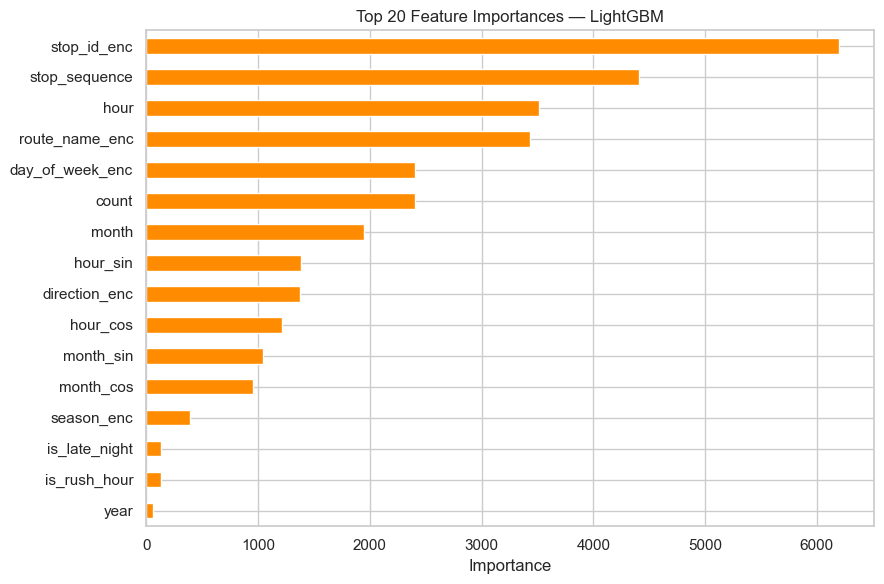

In [13]:
# Pick the best non-linear model to show feature importance
tree_model_names = ['LightGBM', 'Gradient Boosting', 'Random Forest']
best_tree = next(
    (r for r in sorted(results, key=lambda x: x['MAE (s)'])
     if r['Model'] in tree_model_names),
    None
)

if best_tree:
    model_obj = best_tree['_model']
    # Handle Pipeline wrapping
    estimator = model_obj.named_steps['model'] if hasattr(model_obj, 'named_steps') else model_obj
    importances = pd.Series(estimator.feature_importances_, index=X_train.columns)
    importances = importances.sort_values(ascending=True).tail(20)

    plt.figure(figsize=(9, 6))
    importances.plot(kind='barh', color='darkorange')
    plt.title(f'Top 20 Feature Importances — {best_tree["Model"]}', fontsize=12)
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print('No tree model found for feature importances.')

## Residual Analysis (Best Model)

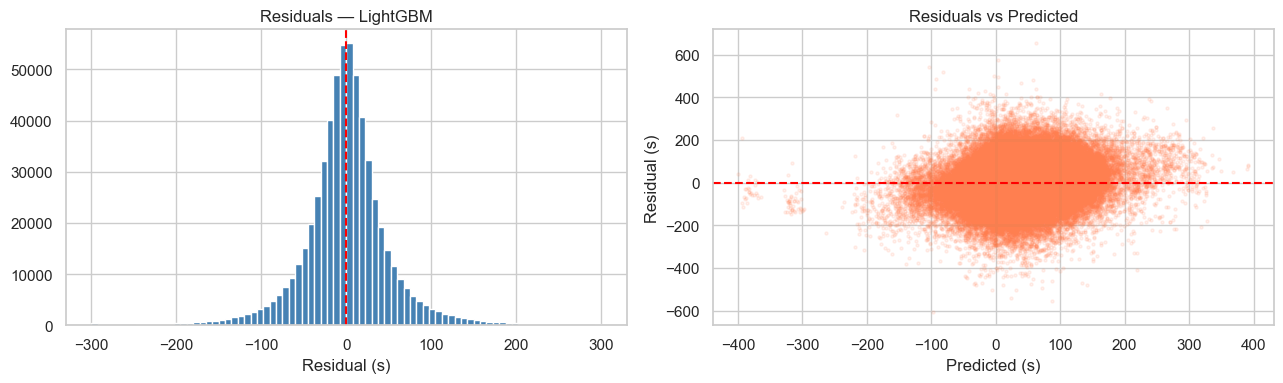


Best model: LightGBM
  MAE : 35.5 seconds
  RMSE: 52.3 seconds
  R²  : 0.3842


In [14]:
best = sorted(results, key=lambda x: x['MAE (s)'])[0]
residuals = y_test.values - best['_preds']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(residuals.clip(-300, 300), bins=80, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title(f'Residuals — {best["Model"]}')
axes[0].set_xlabel('Residual (s)')

axes[1].scatter(best['_preds'], residuals, alpha=0.1, s=5, color='coral')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted (s)')
axes[1].set_ylabel('Residual (s)')

plt.tight_layout()
plt.show()

print(f'\nBest model: {best["Model"]}')
print(f'  MAE : {best["MAE (s)"]:.1f} seconds')
print(f'  RMSE: {best["RMSE (s)"]:.1f} seconds')
print(f'  R²  : {best["R²"]}')

## Save Best Model

In [ ]:
SAVE_DIR = './ml_service/models'
os.makedirs(SAVE_DIR, exist_ok=True)

best_model_obj = best['_model']
model_path = os.path.join(SAVE_DIR, 'delay_model.joblib')
joblib.dump(best_model_obj, model_path)

# Save feature list so the API knows what columns to expect
feature_meta = {
    'model_name': best['Model'],
    'features': X_train.columns.tolist(),
    'target': TARGET_COL,
    'metrics': {
        'MAE_seconds': best['MAE (s)'],
        'RMSE_seconds': best['RMSE (s)'],
        'R2': best['R²'],
        'MAPE_pct': best['MAPE (%)']
    }
}
meta_path = os.path.join(SAVE_DIR, 'model_meta.json')
with open(meta_path, 'w') as f:
    json.dump(feature_meta, f, indent=2)

print(f'Model saved → {model_path}')
print(f'Metadata saved → {meta_path}')
print(json.dumps(feature_meta, indent=2))

## API Contract Preview

Prediction endpoint:

```
POST /api/v1/predict
Content-Type: application/json

{
  "route_name": "7",
  "direction": "Downtown/South",
  "stop_id": "702S",
  "day_of_week": "Thursday",
  "hour": 8,
  "month": 3,
  "year": 2025,
  "stop_sequence": 2,
  "season": "Spring",
  "count": 12
}

→ Response:
{
  "predicted_delay_seconds": 45.3,
  "predicted_delay_minutes": 0.75,
  "model": "LightGBM"
}
```

> **Note:** `holiday` is excluded until the column is fixed. `stop_name` is excluded as `stop_id` captures the same information more precisely.